# **Weather Classification Model**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
import pickle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/Datasets/seattle-weather.csv"
df= pd.read_csv(path)
print(df.head(10))

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
5  2012-01-06            2.5       4.4       2.2   2.2     rain
6  2012-01-07            0.0       7.2       2.8   2.3     rain
7  2012-01-08            0.0      10.0       2.8   2.0      sun
8  2012-01-09            4.3       9.4       5.0   3.4     rain
9  2012-01-10            1.0       6.1       0.6   3.4     rain


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [ ]:
print(df.shape)

(1461, 6)


In [ ]:
df.describe(include='all')

,date,precipitation,temp_max,temp_min,wind,weather
count,1461,1461.000000,1461.000000,1461.000000,1461.000000,1461
unique,1461,NaN,NaN,NaN,NaN,5
top,2015-12-31,NaN,NaN,NaN,NaN,rain
freq,1,NaN,NaN,NaN,NaN,641
mean,NaN,3.029432,16.439083,8.234771,3.241136,NaN
std,NaN,6.680194,7.349758,5.023004,1.437825,NaN
min,NaN,0.000000,-1.600000,-7.100000,0.400000,NaN
25%,NaN,0.000000,10.600000,4.400000,2.200000,NaN
50%,NaN,0.000000,15.600000,8.300000,3.000000,NaN
75%,NaN,2.800000,22.200000,12.200000,4.000000,NaN


In [ ]:
print("Missing Values")
df.isnull().sum()

Missing Values


,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


# Exploratory Data Analysis (EDA)

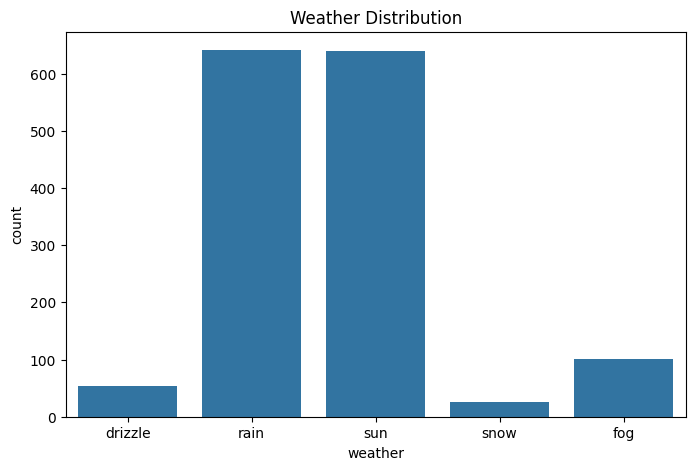

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='weather', data=df)
plt.title('Weather Distribution')
plt.show()


In [ ]:
print("Numerical Feature Summary")
display(df.describe())

Numerical Feature Summary


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


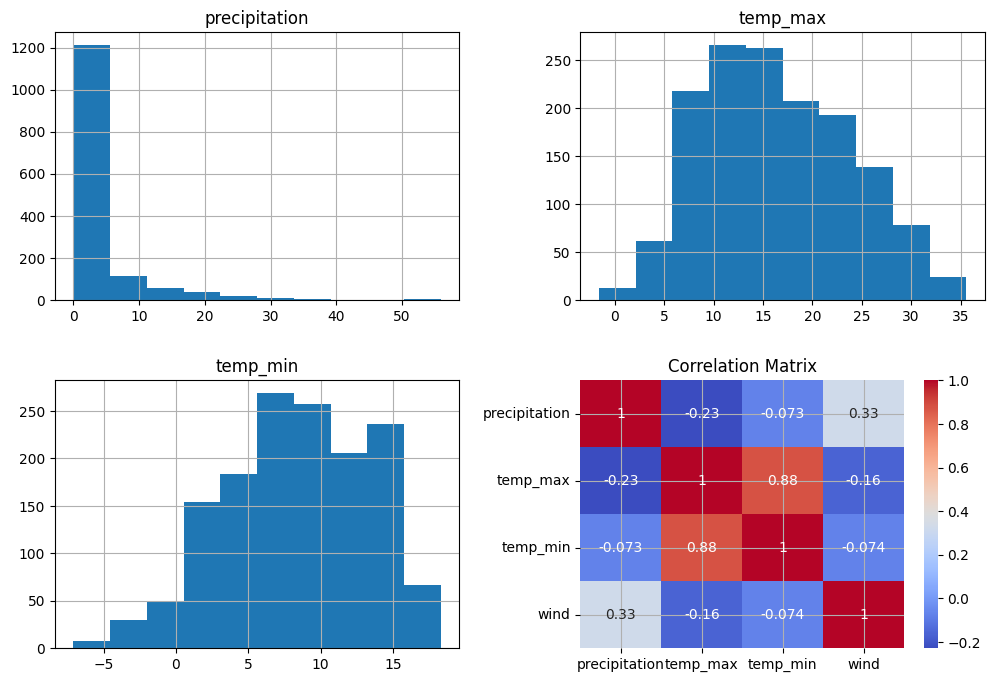

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df.hist(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

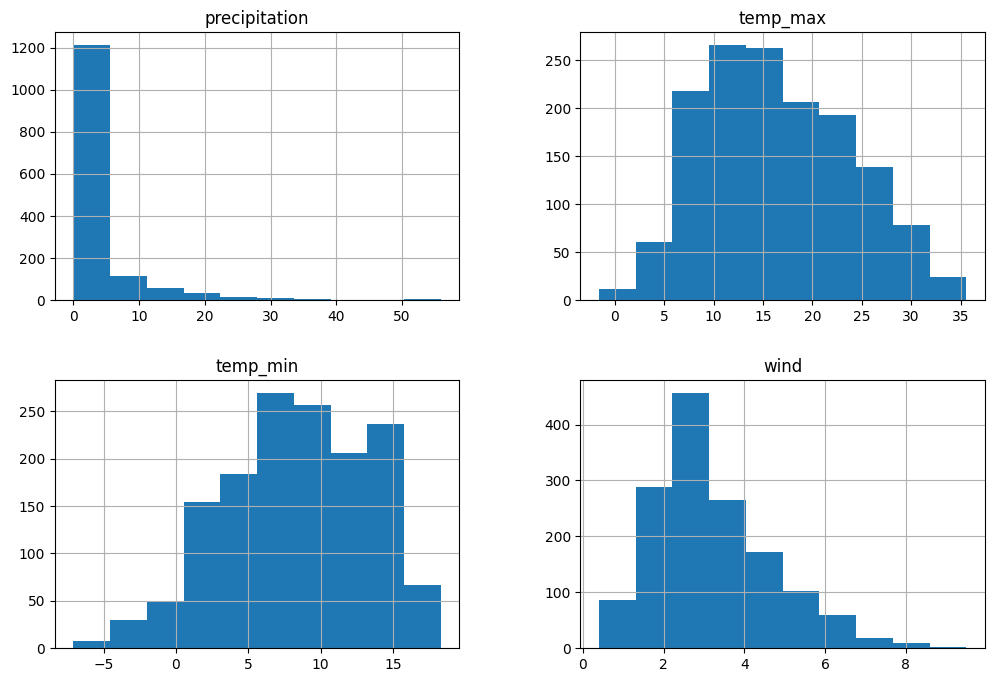

In [ ]:

df.hist(figsize=(12, 8))
plt.show()

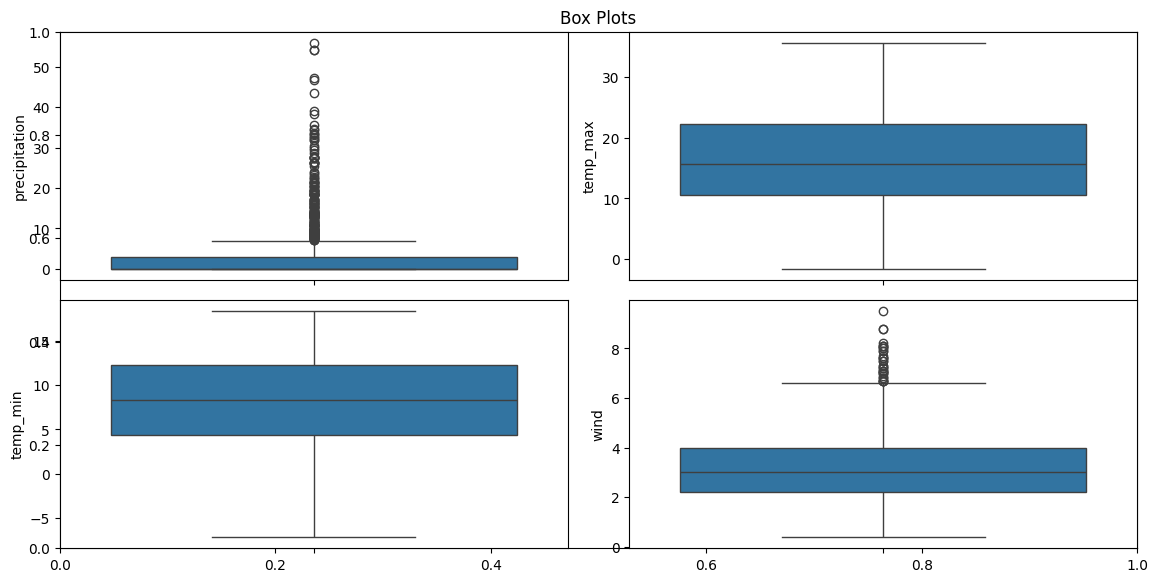

In [ ]:
plt.figure(figsize=(12,6))
plt.title("Box Plots")
for i, col in enumerate(['precipitation', 'temp_max', 'temp_min', 'wind']):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

# Feature Engineering

In [ ]:
df.columns

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

In [ ]:
df["date"]= pd.to_datetime(df["date"])
df["year"]= df["date"].dt.year
df["month"]= df["date"].dt.month
df["day"]= df["date"].dt.day
df["dayofweek"]= df["date"].dt.dayofweek

In [ ]:
df.drop("date", axis=1, inplace=True)

In [ ]:
df.head()

,precipitation,temp_max,temp_min,wind,weather,year,month,day,dayofweek
0,0.0,12.8,5.0,4.7,drizzle,2012,1,1,6
1,10.9,10.6,2.8,4.5,rain,2012,1,2,0
2,0.8,11.7,7.2,2.3,rain,2012,1,3,1
3,20.3,12.2,5.6,4.7,rain,2012,1,4,2
4,1.3,8.9,2.8,6.1,rain,2012,1,5,3


In [ ]:
df.tail()

,precipitation,temp_max,temp_min,wind,weather,year,month,day,dayofweek
1456,8.6,4.4,1.7,2.9,rain,2015,12,27,6
1457,1.5,5.0,1.7,1.3,rain,2015,12,28,0
1458,0.0,7.2,0.6,2.6,fog,2015,12,29,1
1459,0.0,5.6,-1.0,3.4,sun,2015,12,30,2
1460,0.0,5.6,-2.1,3.5,sun,2015,12,31,3


# Encode Target Variable

In [ ]:
le= LabelEncoder()
df["weather"]= le.fit_transform(df["weather"])
weather_mapping = dict(zip(le.classes_ , le.transform(le.classes_)))
print(weather_mapping)

{'drizzle': np.int64(0), 'fog': np.int64(1), 'rain': np.int64(2), 'snow': np.int64(3), 'sun': np.int64(4)}


# Prepare Features Target Variables

In [ ]:
X = df.drop("weather", axis=1)
y = df["weather"]
print(X.shape)
print(y.shape)

(1461, 8)
(1461,)


# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

(1168, 8)
(293, 8)


# Random Forest Model

In [ ]:
rf= RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred= rf.predict(X_test)
rf.fit(X_train, y_train)
pickle.dump(rf, open("weather_rf_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))
y_pred= rf.predict(X_test)
accuracy= accuracy_score(y_test, y_pred)
print("RANDOM FOREST ACCURACY")
print("Accuracy: ", accuracy)


RANDOM FOREST ACCURACY
Accuracy:  0.8464163822525598


In [ ]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.09      0.13        11
           1       1.00      0.25      0.40        20
           2       0.94      0.91      0.93       129
           3       1.00      0.20      0.33         5
           4       0.78      0.96      0.86       128

    accuracy                           0.85       293
   macro avg       0.79      0.48      0.53       293
weighted avg       0.85      0.85      0.82       293



# Confusion Matrix of Random Forest

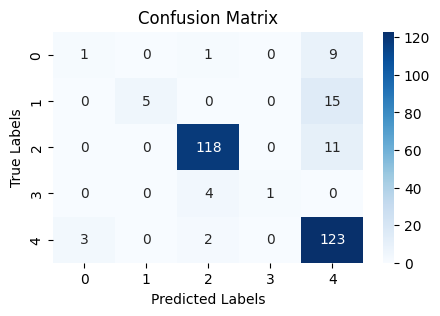

In [ ]:
plt.figure(figsize=(5,3))
cm= confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# XGBoost Model

In [ ]:
xgb= XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred= xgb.predict(X_test)
xgb.fit(X_train, y_train)
y_pred= xgb.predict(X_test)
accuracy= accuracy_score(y_test, y_pred)
print("XGBOOST ACCURACY")
print("Accuracy: ", accuracy)

XGBOOST ACCURACY
Accuracy:  0.8361774744027304


In [ ]:
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.09      0.10        11
           1       0.58      0.35      0.44        20
           2       0.95      0.92      0.94       129
           3       1.00      0.60      0.75         5
           4       0.80      0.90      0.85       128

    accuracy                           0.84       293
   macro avg       0.69      0.57      0.61       293
weighted avg       0.83      0.84      0.83       293



# Confusion Matrix of XGBoost

Text(0.5, 1.0, 'Confusion Matrix')

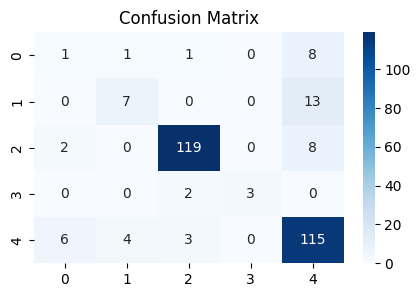

In [ ]:
plt.figure(figsize=(5,3))
cm= confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')

# Predictions

In [ ]:
sample = pd.DataFrame({
    'precipitation':[2.5],
    'temp_max':[18],
    'temp_min':[10],
    'wind':[3.2],
    'year':[2016],
    'month':[6],
    'day':[15],
    'dayofweek':[2]
})
prediction = rf.predict(sample)
print("Predicted Weather: ")
print(le.inverse_transform(prediction))

Predicted Weather: 
['rain']


In [ ]:
sample = pd.DataFrame({
    'precipitation':[2.5],
    'temp_max':[18],
    'temp_min':[10],
    'wind':[3.2],
    'year':[2016],
    'month':[6],
    'day':[15],
    'dayofweek':[2]
})

prediction = xgb.predict(sample)

print("Predicted Weather:")
print(le.inverse_transform(prediction))

Predicted Weather:
['rain']


# Project Workflow
1.   Load Dataset
2.   Data Understanding
3. EDA
4. Data Cleaning
5. Feature Engineering
6. Label Encoding
7. Train/Test Split
8. Random Forest Model
9. XGBoost Model
10. Model Evaluation
11. Final Prediction


